# Week 3 — Real Number Predictor Lab

Goal: train a small PyTorch regression model that predicts `MedHouseVal`
from the California Housing dataset.

This notebook follows the full workflow:

1. load a real tabular dataset
2. split features from the target
3. create train/test sets
4. normalize input features
5. convert data to PyTorch tensors
6. build a baseline linear regression model
7. measure loss
8. train the model
9. evaluate and save artifacts

In [36]:
from pathlib import Path
import pandas as pd
import torch
from torch import nn

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [37]:
def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path

    raise FileNotFoundError("Could not find repository root with pyproject.toml")


repo_root = find_repo_root(Path.cwd())
repo_root

WindowsPath('C:/Users/giloz/dev/intuitive_understanding_machine_learning')

In [38]:
EPOCH_COUNT = 200
LEARNING_RATE = 0.01

In [ ]:
raw_data_dir = repo_root / "data" / "raw"
raw_data_dir.mkdir(parents=True, exist_ok=True)

housing = fetch_california_housing(as_frame=True)
housing_frame = housing.frame

csv_path = raw_data_dir / "week-03-california-housing.csv"
housing_frame.to_csv(csv_path, index=False)
housing_frame.head()

## First look at the data

Each row is one housing example.

The feature columns are the inputs the model can use:

- `MedInc`
- `HouseAge`
- `AveRooms`
- `AveBedrms`
- `Population`
- `AveOccup`
- `Latitude`
- `Longitude`

The target column is `MedHouseVal`, the number the model will try to predict.

This is a regression problem because the target is a number, not a category.
`MedHouseVal` is measured in units of $100,000, so a prediction of `2.35`
means about `$235,000`.

## Train/test split

`X` means the feature table: many rows and 8 input columns.

`y` means the target values: one answer per row.


In [25]:
loaded_frame=pd.read_csv(csv_path)

target_column = "MedHouseVal"
feature_columns = [ c for c in loaded_frame.columns if c != target_column]

X: pd.DataFrame = loaded_frame[feature_columns]
y: pd.DataFrame = loaded_frame[target_column]

X_train: pd.DataFrame
X_test: pd.DataFrame
y_train: pd.Series
y_test: pd.Series

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## Normalization

The feature columns have different scales. For example, population counts can be much larger than average room counts.

To make training smoother, I standardize each feature with:

```text
normalized_value = (original_value - mean) / standard_deviation
```

I calculate the mean and standard deviation from the training data only.
Then I reuse those same training statistics for the test data.


In [26]:
train_means = X_train.mean()
train_stds = X_train.std()

X_train_normalized = (X_train - train_means) / train_stds
X_test_normalized = (X_test - train_means) / train_stds

print(X_train_normalized.mean().round(3))
X_train_normalized.head()


MedInc       -0.0
HouseAge     -0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
dtype: float64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326186,0.348480,-0.174911,-0.208359,0.768253,0.051375,-1.372770,1.272548
8267,-0.035842,1.618069,-0.402823,-0.128526,-0.098898,-0.117359,-0.876669,0.709141
17445,0.144697,-1.952651,0.088213,-0.257530,-0.449804,-0.032279,-0.460133,-0.447590
14265,-1.017834,0.586528,-0.599997,-0.145152,-0.007434,0.077505,-1.382130,1.232661
2271,-0.171483,1.141973,0.348997,0.086622,-0.485862,-0.068830,0.532068,-0.108548


## Convert the data to PyTorch tensors

A tensor is PyTorch's number container.

The model expects input rows shaped like:

```text
[number_of_rows, number_of_features]
```

The target values are reshaped from a plain list into a one-column table:

```text
[16512, 1]
```

The `.reshape(-1, 1)` means: “make this one column, and let PyTorch figure out how many rows there are.”

In [27]:
X_train_tensor = torch.tensor(X_train_normalized.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_normalized.to_numpy(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([16512, 8])
X_test_tensor: torch.Size([4128, 8])
y_train_tensor: torch.Size([16512, 1])
y_test_tensor: torch.Size([4128, 1])


## Model intuition: a weighted recipe

A baseline linear regression model receives 8 input numbers and outputs 1 predicted house value.

It learns 8 weights and 1 bias:

```text
prediction =
    weight_1 * MedInc
  + weight_2 * HouseAge
  + weight_3 * AveRooms
  + weight_4 * AveBedrms
  + weight_5 * Population
  + weight_6 * AveOccup
  + weight_7 * Latitude
  + weight_8 * Longitude
  + bias
```

The weights are learned numbers. During training, PyTorch adjusts them so the predictions become less wrong.

Because this is regression, the model output is not a logit or probability.
It is directly interpreted as the predicted `MedHouseVal`.

## How the model learns the target units

The input features are normalized, but the target `MedHouseVal` is not.

That means the model is trained to answer:

```text
given normalized inputs, output a number close to the original MedHouseVal
```

PyTorch does not know about dollars. The unit comes from the target numbers used in the loss:

```python
loss = loss_function(predictions, y_train_tensor)
```

Because `y_train_tensor` is in `MedHouseVal` units, the model's predictions learn to be in `MedHouseVal` units too.

The normalized input values are unitless. A value like `+1.0` means one standard deviation above the training average, not the maximum.

In [28]:
input_size = X_train_tensor.shape[1]
output_size = 1

model = nn.Linear(in_features=input_size, out_features=output_size)

print(model)
print(f"weight shape: {model.weight.shape}")
print(f"bias shape: {model.bias.shape}")


Linear(in_features=8, out_features=1, bias=True)
weight shape: torch.Size([1, 8])
bias shape: torch.Size([1])


## Loss: measuring wrongness

A prediction is the model's current guess.

An error is:

```text
prediction - true_value
```

For this regression project, I use mean squared error:

```text
squared_error = error * error
loss = average squared_error
```

Loss is one number that summarizes how wrong the model is.
Lower loss is better.

In [29]:
# nn.MSELoss() means mean squared error:
# error = prediction - true_value
# squared_error = error * error
# loss = average squared_error
loss_function = nn.MSELoss()

with torch.no_grad():
    starting_predictions = model(X_train_tensor)
    starting_loss = loss_function(starting_predictions, y_train_tensor)
    
print("starting_predictions shape:", starting_predictions.shape)
print("starting_loss shape:", starting_loss.item())


starting_predictions shape: torch.Size([16512, 1])
starting_loss shape: 6.104740142822266


## Training loop

Training repeats the same learning cycle many times:

```text
predict -> measure loss -> compute gradients -> update parameters
```

In code, the order is:

1. `model(X_train_tensor)` makes predictions
2. `loss_function(...)` measures wrongness
3. `optimizer.zero_grad()` clears old gradients
4. `loss.backward()` computes new gradients
5. `optimizer.step()` updates the weights and bias

If training is working, the loss should generally go down.

In [30]:
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

loss_values = []
for epoch in range(EPOCH_COUNT):
    model.train()
    
    predictions = model(X_train_tensor)
    loss = loss_function(predictions, y_train_tensor)
    
    optimizer.zero_grad() # clear old gradients
    loss.backward() # compute new gradients
    optimizer.step() # update weights and bias
    
    loss_values.append(loss.item())
    
    if epoch % 50 == 0:
        print(f"epoch={epoch}, loss={loss.item():.4f}")

print(f"final loss={loss_values[-1]:.4f}")

epoch=0, loss=6.1047
epoch=50, loss=1.3317
epoch=100, loss=0.7242
epoch=150, loss=0.6286
final loss=0.6040


## What happened during training?

The loss decreased from about `5.47` to about `0.57`.

That means the model's predictions became less wrong on the training data.

The next question is whether the model also works on test data it has not seen (generalization).

In [31]:
model.eval()

with torch.no_grad():
    final_train_predictions = model(X_train_tensor)
    final_train_loss = loss_function(final_train_predictions, y_train_tensor)
    
    test_predictions = model(X_test_tensor)
    test_loss = loss_function(test_predictions, y_test_tensor)
    
print(f"final train loss: {final_train_loss.item():.4f}")
print(f"test loss: {test_loss.item():.4f}")

final train loss: 0.6036
test loss: 0.6169


In [32]:
comparison = pd.DataFrame({
       "predicted_MedHouseVal": test_predictions[:10].squeeze().numpy(),
       "actual_MedHouseVal": y_test_tensor[:10].squeeze().numpy(),
   })

comparison["predicted_dollars"] = comparison["predicted_MedHouseVal"] * 100_000
comparison["actual_dollars"] = comparison["actual_MedHouseVal"] * 100_000

comparison

,predicted_MedHouseVal,actual_MedHouseVal,predicted_dollars,actual_dollars
0,0.983972,0.47700,98397.179688,47700.000000
1,1.542707,0.45800,154270.656250,45800.000000
2,2.314892,5.00001,231489.203125,500001.000000
3,2.671780,2.18600,267178.000000,218600.015625
4,2.118640,2.78000,211863.968750,278000.000000
5,2.125479,1.58700,212547.921875,158700.000000
6,2.673563,1.98200,267356.312500,198200.000000
7,2.142220,1.57500,214221.953125,157500.000000
8,2.115263,3.40000,211526.296875,340000.000000
9,4.075730,4.46600,407573.000000,446600.000000


In [33]:
train_rmse = final_train_loss.sqrt()
test_rmse = test_loss.sqrt()

print(f"train RMSE in MedHouseVal units: {train_rmse.item():.4f}")
print(f"test RMSE in MedHouseVal units: {test_rmse.item():.4f}")
print(f"test RMSE in dollars: ${test_rmse.item() * 100_000:,.0f}")

train RMSE in MedHouseVal units: 0.7769
test RMSE in MedHouseVal units: 0.7854
test RMSE in dollars: $78,544


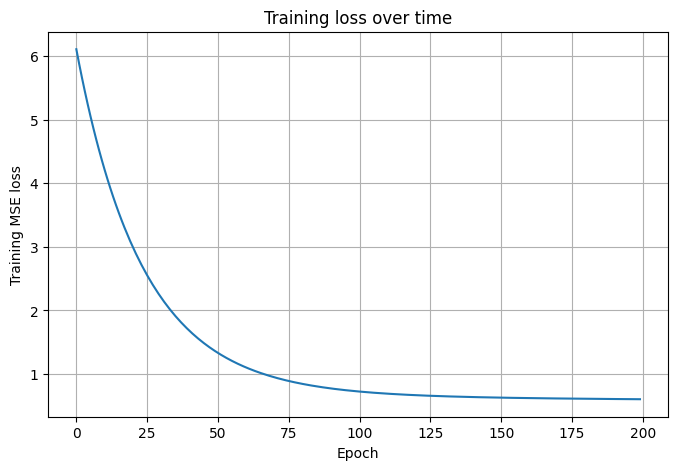

WindowsPath('C:/Users/giloz/dev/intuitive_understanding_machine_learning/artifacts/week-03-number-prediction/loss_curve.png')

In [34]:
import matplotlib.pyplot as plt

artifact_dir = Path(f"{repo_root}/artifacts/week-03-number-prediction")
artifact_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("Training MSE loss")
plt.title("Training loss over time")
plt.grid(True)

loss_curve_path = artifact_dir / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()

loss_curve_path

In [35]:
print("current working directory:", Path.cwd())
print("loss_curve_path:", loss_curve_path)
print("resolved loss_curve_path:", loss_curve_path.resolve())
print("loss_curve exists:", loss_curve_path.exists())

current working directory: C:\Users\giloz\dev\intuitive_understanding_machine_learning\weeks\week-03-number-prediction
loss_curve_path: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-03-number-prediction\loss_curve.png
resolved loss_curve_path: C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-03-number-prediction\loss_curve.png
loss_curve exists: True
